## **Topic 2**


### Intro to AI and Data Science


- **AI**

  - Technology to simulate human intelligence

  1. Acting Humanly
  2. Thinking Humanly
  3. Acting Rationally
  4. Thinking Rationally

- **Data Science**

  - Extract meaningful insights from data for decision making

  1. Big Data - Enormous Complex Data
  2. Data driven decision making
     - Reduce Risks
     - Cost Savings

- **Application**: _AI for Human Resource Management_
  1. Talent Acquisition (TA)
  2. Learning and Training Programs
  3. Internal Employee Management
  4. Onboarding of new recruits


### Data Wrangling


`Data Munging`, `Data Remediation`

- Clean, transform and prepare raw data into format suited for analysis
- To ensure reliability and completeness of dataset
- Enhance accuracy and value of insights from data

**Six Steps of Data Wrangling**
| **Step** | **Description** |
|----------------|----------------------------------------------------------------------------------|
| **1. Discovery** | Identify data sources, assess data quality, and understand data format/structure. |
| **2. Structuring** | Reshape, convert, and fill missing data to ensure a standardized data presentation. |
| **3. Cleaning** | Handle inaccuracies, remove duplicates, and fix anomalies for error-free data. |
| **4. Enriching** | Merge with external sources and augment data for deeper comprehension. |
| **5. Validation** | Ensure data meets quality and integrity standards required for analysis. |
| **6. Publishing** | Document the entire process and prepare data for storage or integration. |


**Titanic Dataset Use Case**


In [547]:
import pandas as pd
import requests
from pathlib import Path

datapath = Path('Data')
datapath.mkdir(parents=True, exist_ok=True)
filepath = datapath / 'titanic_train.csv'

response = requests.get("https://raw.githubusercontent.com/prof-sushil/Data-Science-World/refs/heads/main/data/titanic_train.csv")
with open(filepath, "wb") as f:
    f.write(response.content)

print(f"File saved to {filepath}")

File saved to Data\titanic_train.csv


In [548]:
# Working with the dataset
df = pd.read_csv("Data/titanic_train.csv")
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [549]:
df.shape # Rows (Datapoints), Columns

(891, 12)

In [550]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [551]:
df.describe() # Statistical Description

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [552]:
df.info() # Summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [553]:
# Inspecting the data
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [554]:
df.duplicated().sum() # No duplicates

np.int64(0)

In [555]:
# Checking an important column
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

**Handling Missing Values**

- Impute (Predictive Models, Group Stats, Mean , Median, Mode)
- Drop missing (If number is large)


In [556]:
df["Cabin"].isnull().sum() # Large number of missing

np.int64(687)

In [557]:
df["Age"].isnull().sum() # Fairly low

np.int64(177)

In [558]:
df["Embarked"].isnull().sum() # Negligible

np.int64(2)

In [559]:
# Drop Cabin
df = df.drop("Cabin", axis=1)

# Mean Imputation for Age
mean_age = df["Age"].mean()
df["Age"] = df["Age"].fillna(mean_age)

# Mode Imputation for Embarked
mode_embarked = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(mode_embarked)

# Checking after handling all missing values
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

**Feature types:**

1. Categorical

   - Nominal: Unordered, no quantitative values\
     - Example: (RGB), (Male, Female)
   - Ordinal: Ordered, Ranked
     - Example: (Poor, Fair, Good), (Unsatisfied, Neutral, Satisfied)

2. Numeric
   - Discrete: Integer
   - Continuous: Float

**Encoding Categorical Values**

- Convert to Numerical Format

  - **Label Encoding**: Ordinal

    - Assign unique integer to each category
      - Example: (Bad, Neutral, Good) ➡️ (0, 1, 2)

  - **One Hot Encoding**: Nominal

    - Column representation of presence and absence

      - Example: [Red, Yellow, Green] ➡️ [1, 0, 0]

    - OHE Drawback

      - Increased dimensionality
      - Computational inefficiency

    - Solution is **Frequency Encoding**


In [560]:
columns = df.columns
columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [561]:
categorical = df.dtypes[df.dtypes == "object"].index
categorical

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')

In [562]:
numerical = df.dtypes[df.dtypes == "int"].index
numerical

Index(['PassengerId', 'Survived', 'Pclass', 'SibSp', 'Parch'], dtype='object')

In [563]:
# Unique Categorical
for cat in categorical:
    print(f"Number of unique values in {cat}: {len(df[cat].unique())}")

Number of unique values in Name: 891
Number of unique values in Sex: 2
Number of unique values in Ticket: 681
Number of unique values in Embarked: 3


In [564]:
"""
Using One Hot Encoding on Name, Ticket isn't efficient 
But we can apply OHE on Sex, Embarked
"""
df_SeEmb = df[["Sex", "Embarked"]]
df_SeEmb

,Sex,Embarked
0,male,S
1,female,C
2,female,S
3,female,S
4,male,S
...,...,...
886,male,S
887,female,S
888,female,S
889,male,C


In [565]:
df_SeEmb_encoded = pd.get_dummies(df_SeEmb) # Add. Args `columns`, `drop_first`
df_SeEmb_encoded

"""
`drop_first`: Keeps all info, uses fewer columns
"""

'\n`drop_first`: Keeps all info, uses fewer columns\n'

In [566]:
df_SeEmb_encoded.shape

(891, 5)

In [567]:
# Using SkLearn for Label Encoding
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df_copy = df.copy()

df_copy["Embarked"] = label_encoder.fit_transform(df_copy["Embarked"])

df_copy.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.00,2
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.00,2
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.45,2
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.00,0
890,891,0,3,"Dooley, Mr. Patrick",male,32.000000,0,0,370376,7.75,1


In [568]:
# Saving the cleaned dataset
df_SeEmb_encoded.to_csv("Data/cleaned_SeEmb.csv", index=False)

### Data Visualization


**Matplotlib**

- Visualization library for Python


In [569]:
import matplotlib
import matplotlib.pyplot as plt

print(f"Matplotlib Version: {matplotlib.__version__}")

Matplotlib Version: 3.9.4


[]

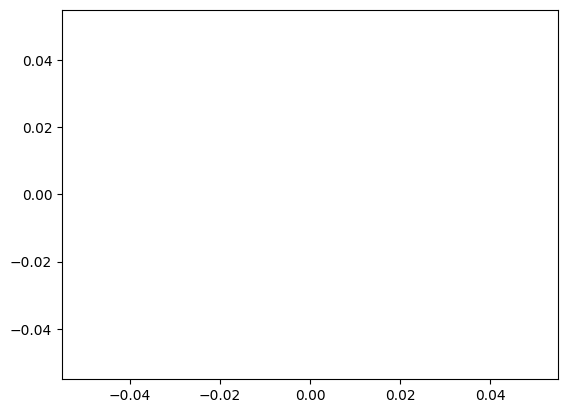

In [570]:
# Simple Plotting
plt.plot()

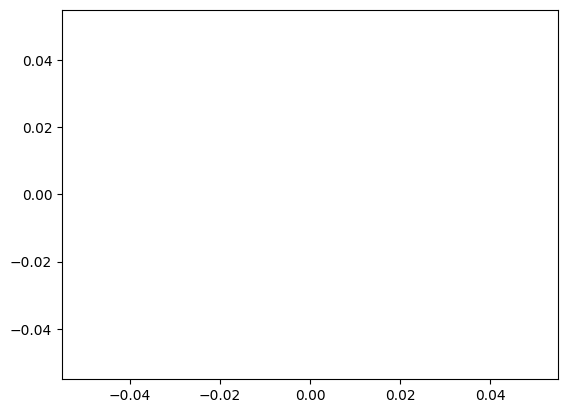

In [571]:
plt.plot();

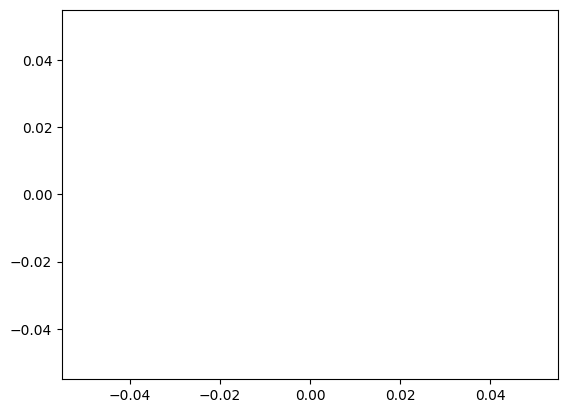

In [572]:
plt.plot() # Same as using plt.plot();
plt.show()

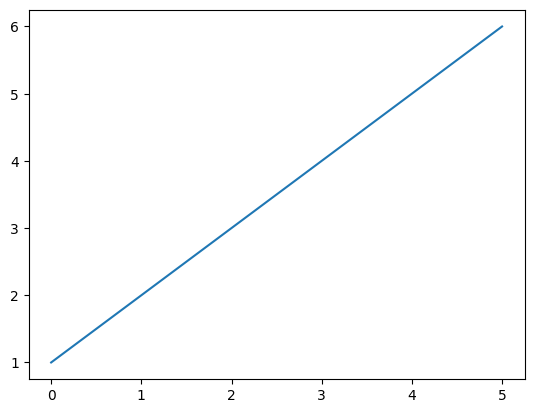

In [573]:
plt.plot([1,2,3,4,5,6])

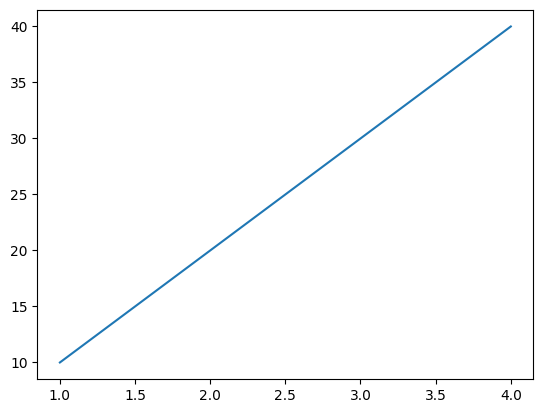

In [574]:
# Using custom data (x, y)
x = [1,2,3,4] 
y = [10,20,30,40]

plt.plot(x, y)

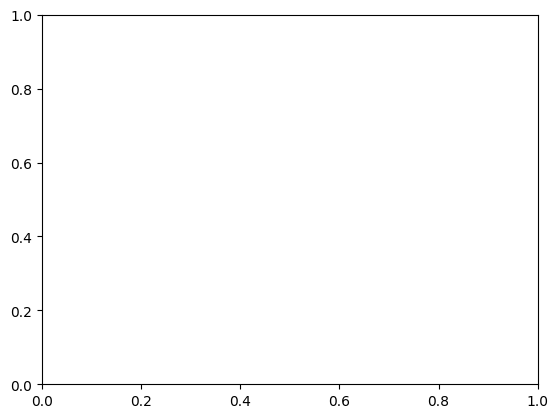

In [575]:
# Object Oriented Version
fig = plt.figure() # Create Figure
ax = fig.add_subplot() # Add an axes
plt.show()

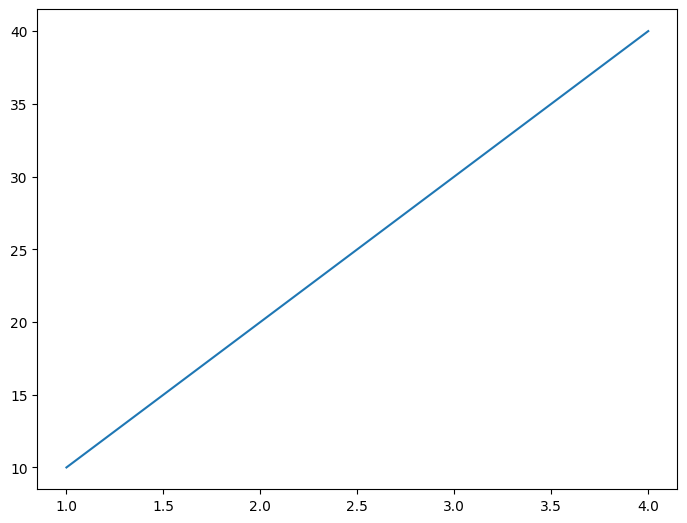

In [576]:
fig = plt.figure()
ax = fig.add_axes([1,1,1,1]) # left, bottom, width, height
ax.plot(x, y)
plt.show()

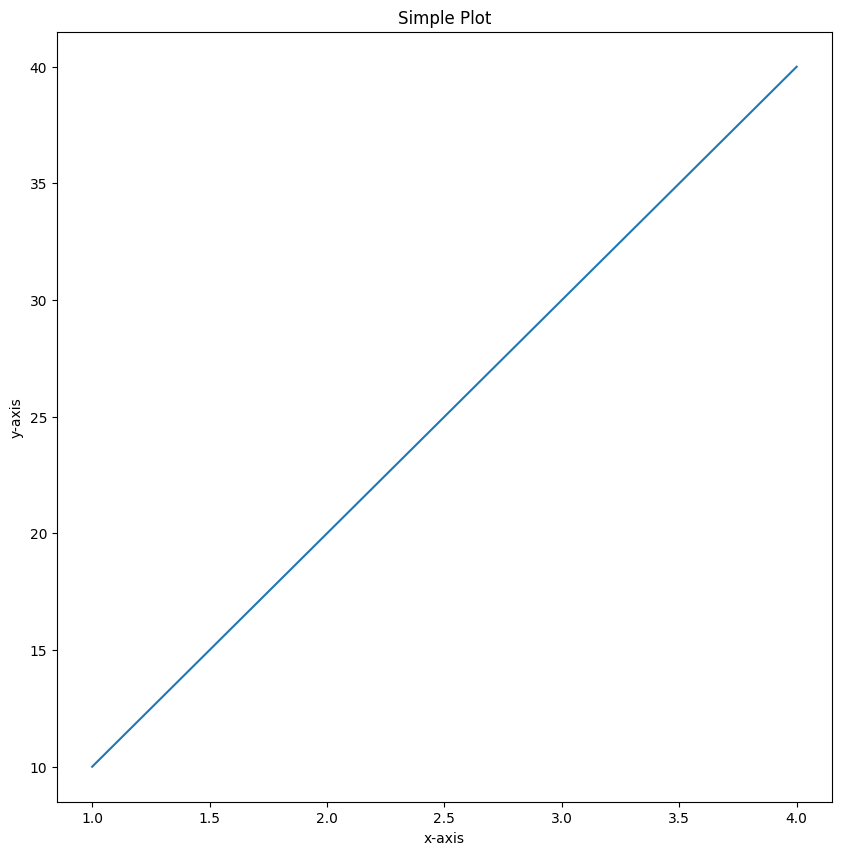

In [577]:
fig, ax = plt.subplots(figsize=(10,10))
ax.set(title="Simple Plot", xlabel="x-axis", ylabel="y-axis")
ax.plot(x, y);

fig.savefig("Data/simpleplot.png")

In [578]:
type(fig), type(ax)

(matplotlib.figure.Figure, matplotlib.axes._axes.Axes)

In [579]:
# Matplotlib visualizations built on NumPy Arrays
#   Line, Scatter, Bar, Histogram Plots

import numpy as np
x = np.linspace(0, 10, 100)
x[:10]

array([0.        , 0.1010101 , 0.2020202 , 0.3030303 , 0.4040404 ,
       0.50505051, 0.60606061, 0.70707071, 0.80808081, 0.90909091])

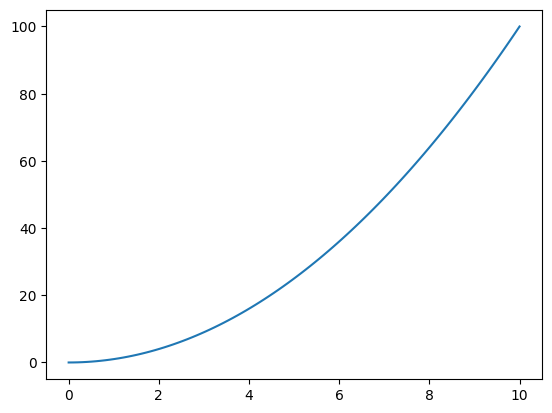

In [580]:
fig, ax = plt.subplots()
ax.plot(x, x**2); # (x, y), Quadratic

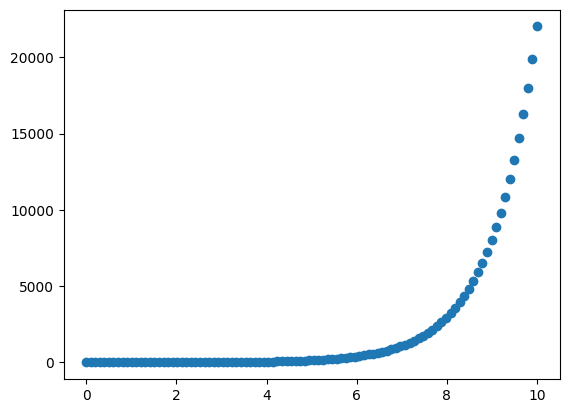

In [581]:
fig, ax = plt.subplots()
ax.scatter(x, np.exp(x));

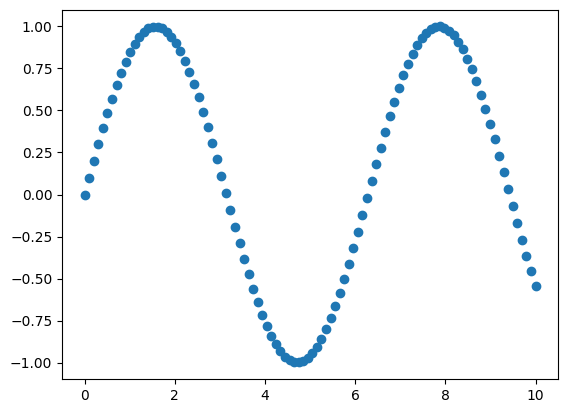

In [582]:
fig, ax = plt.subplots()
ax.scatter(x, np.sin(x));

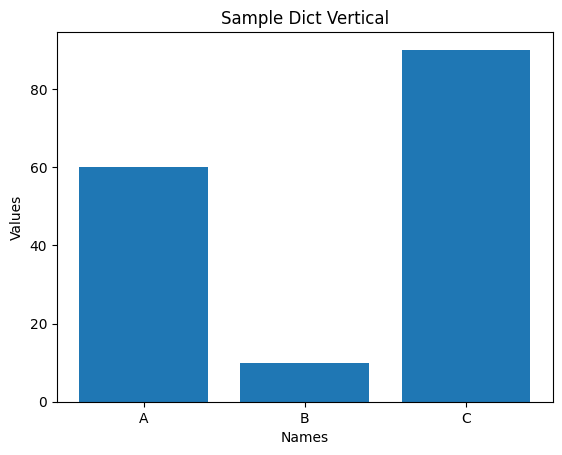

In [583]:
# Bar Plots
#   ax.bar() for Vertical
#   ax.barh() for Horizontal

sample_dict = {"A": 60,
               "B": 10,
               "C": 90}

fig, ax = plt.subplots()
ax.bar(sample_dict.keys(), sample_dict.values())
ax.set(title="Sample Dict Vertical", xlabel="Names", ylabel="Values");

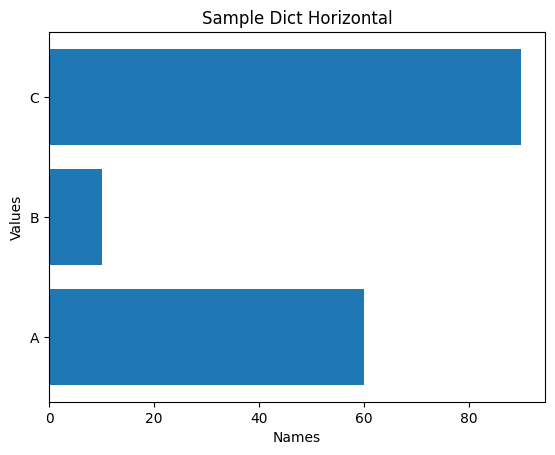

In [584]:
fig, ax = plt.subplots()
ax.barh(sample_dict.keys(), sample_dict.values())
ax.set(title="Sample Dict Horizontal", xlabel="Names", ylabel="Values");

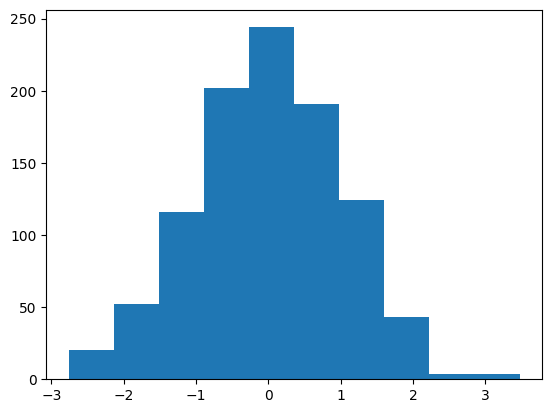

In [585]:
# Histogram: Distribution over a large range
x = np.random.randn(1000) # `randn` Normal, `random` Random

fig, ax = plt.subplots()
ax.hist(x);

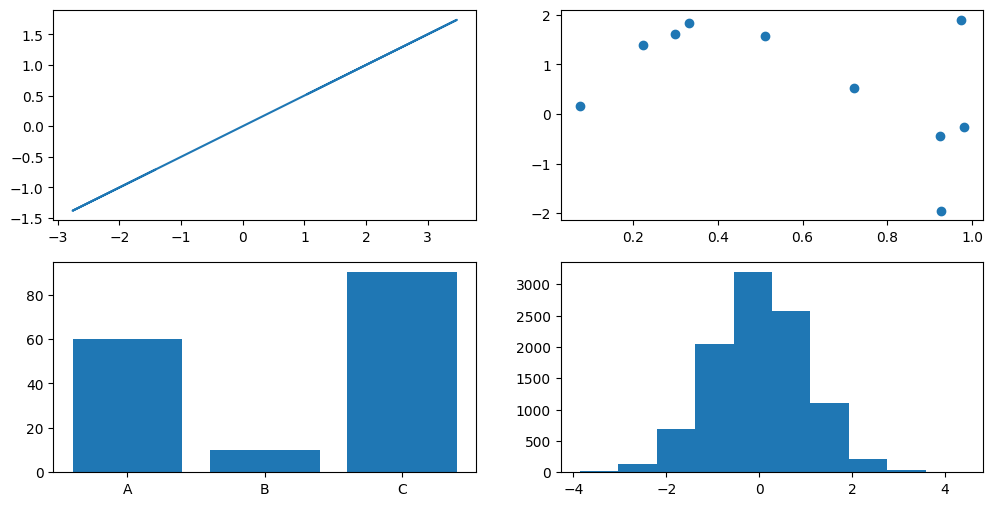

In [586]:
# Subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2,
                                             ncols=2,
                                             figsize=(12,6))

ax1.plot(x, x/2);
ax2.scatter(np.random.random(10), np.random.randn(10));
ax3.bar(sample_dict.keys(), sample_dict.values());
ax4.hist(np.random.randn(10000));

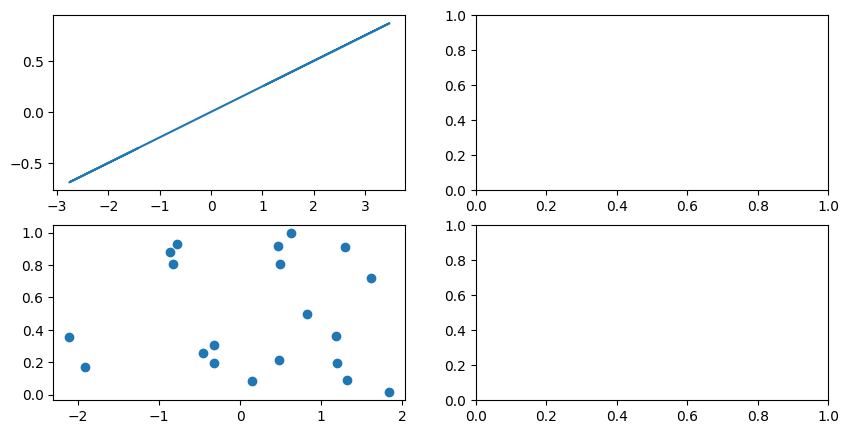

In [587]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,5)) # 2*2 Matrix
ax[0,0].plot(x, x/4);
ax[1,0].scatter(np.random.randn(20), np.random.random(20));

In [588]:
# Plot directly with Pandas
ts = pd.Series(np.random.randn(1000),
               index=pd.date_range('2/2/2025', periods=1000))

ts

2025-02-02   -0.341218
2025-02-03    0.791798
2025-02-04   -0.764029
2025-02-05   -0.943887
2025-02-06    1.207207
                ...   
2027-10-25   -0.984732
2027-10-26    0.175359
2027-10-27   -1.941213
2027-10-28    1.117977
2027-10-29   -0.169700
Freq: D, Length: 1000, dtype: float64

In [589]:
ts.cumsum() # Cumulative Sum

2025-02-02    -0.341218
2025-02-03     0.450580
2025-02-04    -0.313449
2025-02-05    -1.257335
2025-02-06    -0.050128
                ...    
2027-10-25    24.794307
2027-10-26    24.969666
2027-10-27    23.028453
2027-10-28    24.146430
2027-10-29    23.976730
Freq: D, Length: 1000, dtype: float64

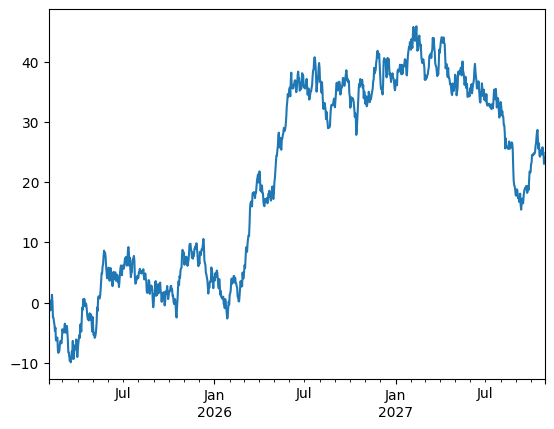

In [590]:
ts.cumsum().plot();

In [591]:
carsales = {"sales": np.random.randint(10000, 100000, size=10),
            "sales_date": pd.date_range("1/1/2024", periods=10)}

df = pd.DataFrame(carsales)
df

,sales,sales_date
0,17006,2024-01-01
1,44188,2024-01-02
2,20688,2024-01-03
3,18626,2024-01-04
4,40632,2024-01-05
5,67398,2024-01-06
6,96842,2024-01-07
7,32097,2024-01-08
8,48792,2024-01-09
9,69161,2024-01-10


In [592]:
df["sales"] = df["sales"] // 10


In [593]:
df.head(3)

,sales,sales_date
0,1700,2024-01-01
1,4418,2024-01-02
2,2068,2024-01-03


In [594]:
df["total_sales"] = df["sales"].cumsum()

In [595]:
df.head(3)

,sales,sales_date,total_sales
0,1700,2024-01-01,1700
1,4418,2024-01-02,6118
2,2068,2024-01-03,8186


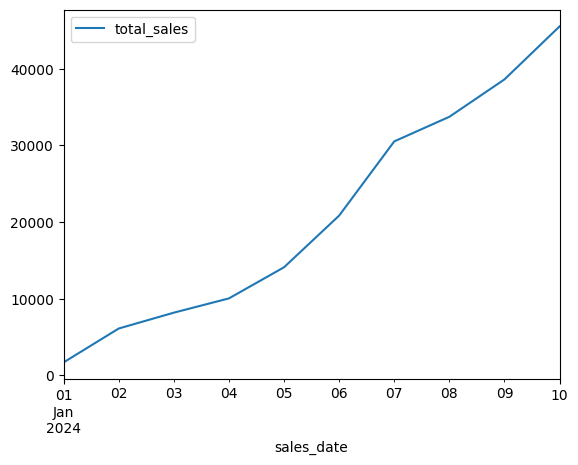

In [596]:
df.plot(x="sales_date", y="total_sales");

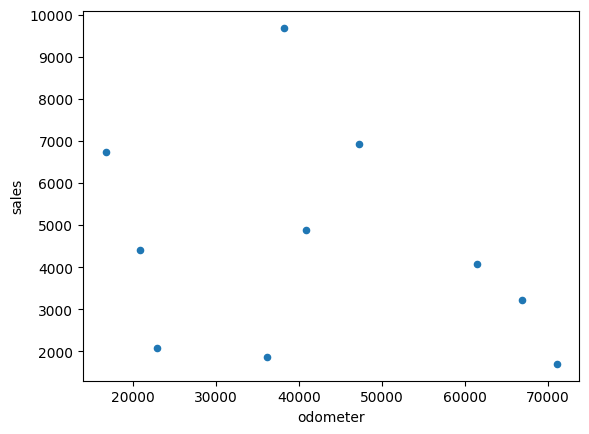

In [597]:
df["odometer"] = np.random.randint(10000, 100000, size=10)
df.plot(x="odometer", y="sales", kind="scatter");

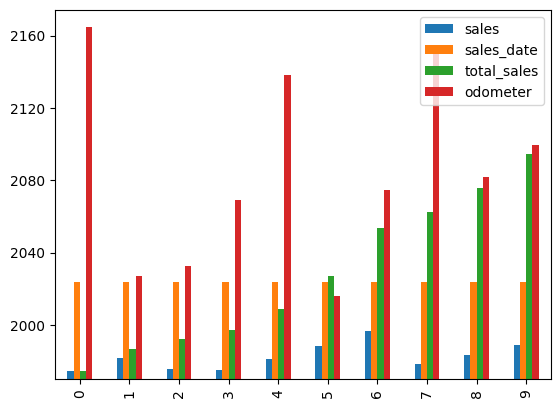

In [598]:
df.plot.bar();

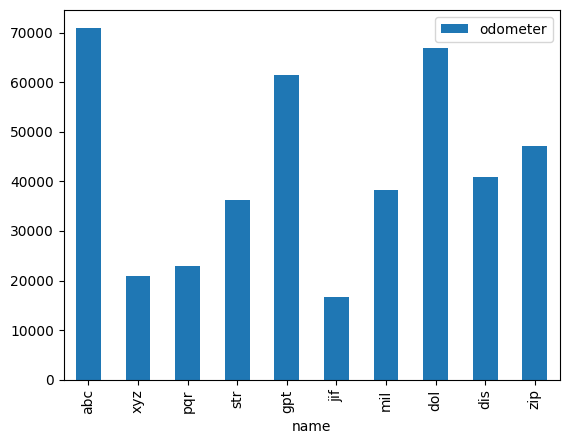

In [599]:
df["name"] = ['abc', 'xyz', 'pqr', 'str', 'gpt', 'jif', 'mil', 'dol', 'dis', 'zip']
df.plot(x="name",
        y="odometer",
        kind="bar");

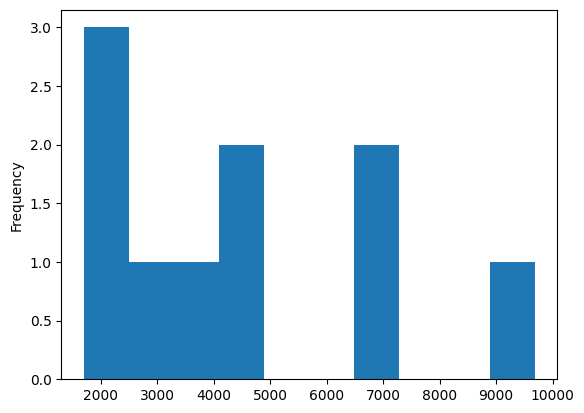

In [600]:
df["sales"].plot.hist(bins=10);

### EDA


- After data wrangling, understand underlying pattern, relationships between variables in the datasets

  - Identify anomalies, structure

- Distribution: How the dataset is spread out, Visualize through shape

- Outlier: Value significantly different (lower, higher)


In [601]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import requests

In [602]:
datapath = Path('Data')
datapath.mkdir(parents=True, exist_ok=True)
filepath = datapath / 'titanic_clean.csv'

response = requests.get("https://raw.githubusercontent.com/prof-sushil/Data-Science-World/refs/heads/main/data/titanic_clean.csv")
with open(filepath, "wb") as f:
    f.write(response.content)

print(f"Cleaned Titanic Data saved at {filepath}")

Cleaned Titanic Data saved at Data\titanic_clean.csv


In [603]:
df = pd.read_csv("Data/titanic_clean.csv")
df.head(3)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True


In [604]:
df = df.set_index("PassengerId")

In [605]:
df.describe(include='all')

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891,891,891
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,True,False,True
freq,NaN,NaN,NaN,NaN,NaN,NaN,577,814,646
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208,NaN,NaN,NaN
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429,NaN,NaN,NaN
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,NaN,NaN,NaN
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN


In [606]:
df.shape

(891, 9)

In [607]:
df.info() # No missing values

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    bool   
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 51.3 KB


**Univariate Analysis**

- Visualizing one feature at a time
  - Histplot for Numeric distributions
  - Countplot for Categorical


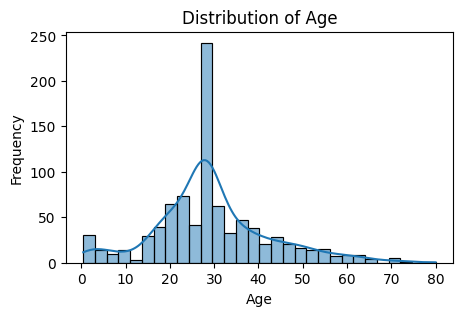

In [608]:
plt.figure(figsize=(5, 3))
sns.histplot(data=df["Age"], bins=30, kde=True)
# Bins: Interval data is grouped in
# kde: Smooth curve to estimate probability density

plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Bell Shaped

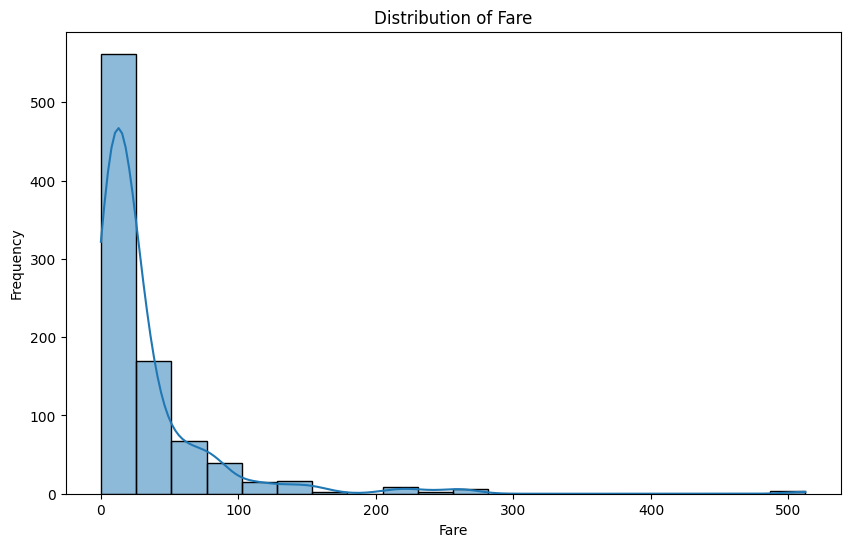

In [609]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df["Fare"], bins=20, kde=True)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

# Skewed

- **Skewed Distribution**

  - Neither symmetric nor normal
  - Data trails off sharply to one side
  - Left skewed: Long left tail and vice versa
  - Viewed by histplot, boxplot

- **Boxplot Skewness**

  - Box and Whiskers
    - Box is 50 % of the data
    - Whiskers are 25 % each
    - Inter Quartile Range (IQR) between Q3 and Q1
    - End of Whisker (Max, Min values), Last point that is 1.5 of IQR

- **Transformations**
  1. Logarithmic: Right Skewed (No zeros, Negatives), Big Values
  2. Square Root Transformation: Count like data
  3. Cube Root Transformation: Positive and Negative
  4. Box Cox Transformation: Postives only


In [610]:
print("Skewness value of Fare: ", df["Fare"].skew())
print("Skewness value of Age: ", df["Age"].skew())

Skewness value of Fare:  4.787316519674893
Skewness value of Age:  0.5102446555756495


In [611]:
df["Fare_log"] = np.log1p(df["Fare"])
print("Skewness value of Fare: ", df["Fare_log"].skew())

Skewness value of Fare:  0.3949280095189306


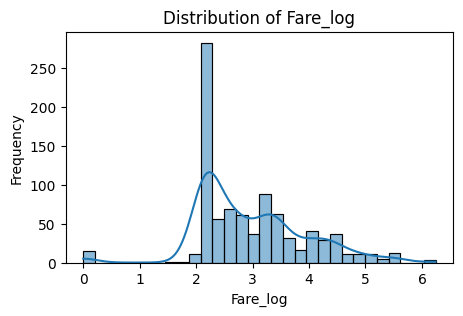

In [612]:
plt.figure(figsize=(5, 3))
sns.histplot(data=df["Fare_log"], bins=30, kde=True)
plt.title('Distribution of Fare_log')
plt.xlabel('Fare_log')
plt.ylabel('Frequency')
plt.show() # Looks normal

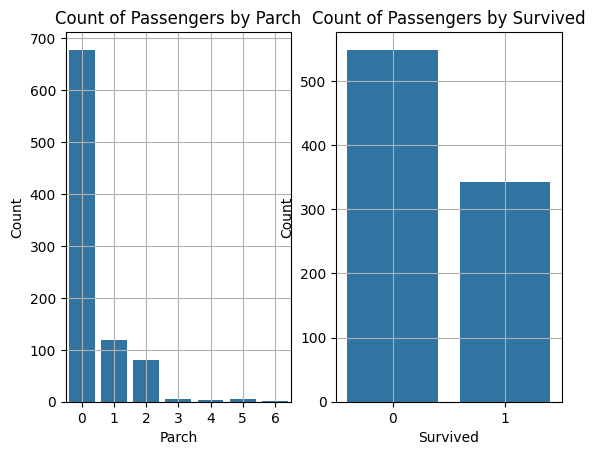

In [613]:
plt.subplot(1, 2, 1)
sns.countplot(x='Parch', data=df)
plt.title('Count of Passengers by Parch')
plt.xlabel('Parch')
plt.ylabel('Count')
plt.grid(True)

# Distribution of 'Survived'
plt.subplot(1, 2, 2)
sns.countplot(x='Survived', data=df)
plt.title('Count of Passengers by Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.grid(True)
plt.show()

**Bivariate Analysis**

- Relationship between different variables
- Scatter plots, Box plots, Correlation matrices


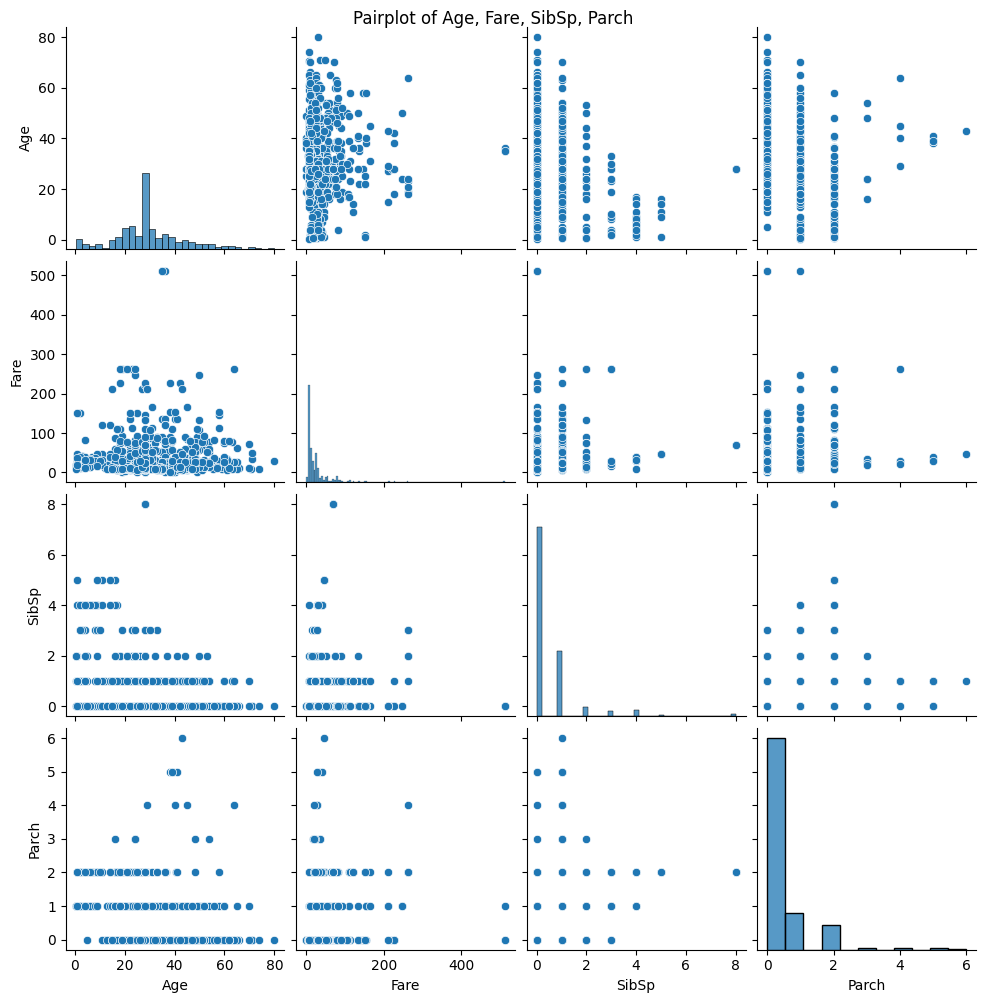

In [614]:
pairplot_columns = ['Age', 'Fare', 'SibSp', 'Parch']
sns.pairplot(df[pairplot_columns])
plt.suptitle("Pairplot of Age, Fare, SibSp, Parch", y=1.0)
plt.show()

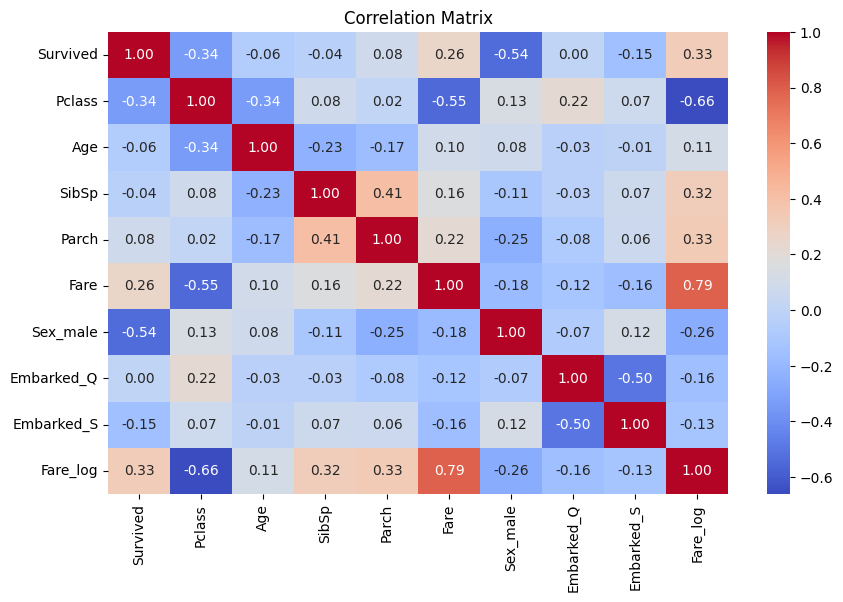

In [615]:
# Correlation
plt.figure(figsize=(10, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

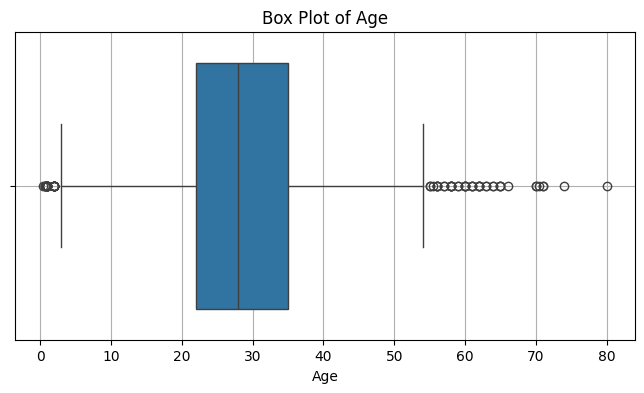

In [616]:
# Boxplots
# Box plot for 'Age' column
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Age'])
plt.title('Box Plot of Age')
plt.xlabel('Age')
plt.grid()
plt.show()

**Handling Outliers**

1. Removal: Completely remove
2. Cap Outliers: Replace with specific percentile
3. Transformation: Reduce impact of outliers
4. Imputation
5. Z-score Method: Remove based on standard deviation from mean
   - For normally distributed data
   - Threshold 3 or -3
